In [1]:
import numpy as np
from scipy.optimize import minimize
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
tb1 = pd.read_excel('mle.xlsx')
tb1

,Id,Y,X
0,1,2,1
1,2,6,4
2,3,7,5
3,4,9,6
4,5,15,9


In [3]:
import statsmodels.api as sm
x = tb1['X']
y = tb1['Y']
x2 = sm.add_constant(x)
mod1 = sm.OLS(y, x2)
mod12 = mod1.fit()
print(mod12.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     145.9
Date:                Tue, 10 Mar 2026   Prob (F-statistic):            0.00122
Time:                        00:34:51   Log-Likelihood:                -4.5811
No. Observations:                   5   AIC:                             13.16
Df Residuals:                       3   BIC:                             12.38
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2882      0.755     -0.382      0.7

C:\Users\vashi\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [4]:
e = mod12.resid
e

0    0.670588
1   -0.182353
2   -0.800000
3   -0.417647
4    0.729412
dtype: float64

In [5]:
np.std(e)

0.604882098380483

In [6]:
def lik(parameters):
    m = parameters[0]
    b = parameters[1]
    sigma = parameters[2]
    for i in np.arange(0, len(x)):
        y_exp = m * x + b
    L = (len(x)/2 * np.log(2 * np.pi) + len(x)/2 * np.log(sigma ** 2) + 1 / 
          (2 * sigma ** 2) * sum((y - y_exp) ** 2))
    return L

In [7]:
lik_model = minimize(lik, np.array([3,3,4]), method = 'L-BFGS-B')

In [8]:
lik_model

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 4.581084072760656
        x: [ 1.618e+00 -2.882e-01  6.049e-01]
      nit: 20
      jac: [ 2.576e-06 -4.441e-07  2.398e-06]
     nfev: 124
     njev: 31
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [9]:
lik_model.x

array([ 1.61764708, -0.28823541,  0.60488218])

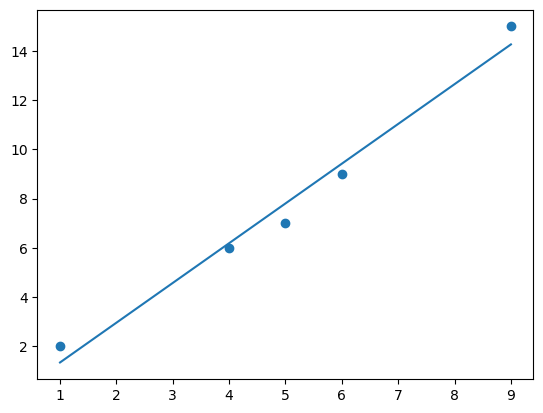

In [10]:
plt.scatter(x, y)
plt.plot(x, lik_model['x'][0] * x + lik_model['x'][1])
plt.show()